<a href="https://colab.research.google.com/github/dhanushkumar-amk/BUILD-OWN-XYZ/blob/main/Building_a_Neural_Network_from_Scratch_with_NumPy_%E2%80%94_Full_Visualization_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Setup & Load Data**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist  # just used to fetch the dataset, not for the model
import seaborn as sns
from sklearn.metrics import confusion_matrix

np.random.seed(42)

# Load MNIST: 60,000 train + 10,000 test images, 28x28 grayscale digits
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

# Flatten 28x28 -> 784, normalize to [0,1]
X_train = X_train_raw.reshape(-1, 784).astype(np.float32) / 255.0
X_test = X_test_raw.reshape(-1, 784).astype(np.float32) / 255.0

# One-hot encode labels
def one_hot(y, num_classes=10):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

y_train = one_hot(y_train_raw)
y_test = one_hot(y_test_raw)

# Transpose so each COLUMN is one sample (standard NN-from-scratch convention)
X_train, X_test = X_train.T, X_test.T
y_train, y_test = y_train.T, y_test.T

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
X_train: (784, 60000), y_train: (10, 60000)


## **The Neural Network Class (pure NumPy)**

In [ ]:
class NeuralNetwork:
    def __init__(self, layer_sizes, seed=42):
        """
        layer_sizes: e.g. [784, 128, 64, 10]
        Uses He initialization, ReLU for hidden layers, softmax for output.
        """
        np.random.seed(seed)
        self.L = len(layer_sizes) - 1
        self.params = {}
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * np.sqrt(2. / layer_sizes[l-1])
            self.params[f"b{l}"] = np.zeros((layer_sizes[l], 1))

        # Adam optimizer state
        self.m, self.v = {}, {}
        for l in range(1, self.L + 1):
            self.m[f"W{l}"] = np.zeros_like(self.params[f"W{l}"])
            self.v[f"W{l}"] = np.zeros_like(self.params[f"W{l}"])
            self.m[f"b{l}"] = np.zeros_like(self.params[f"b{l}"])
            self.v[f"b{l}"] = np.zeros_like(self.params[f"b{l}"])
        self.t = 0

        self.history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    @staticmethod
    def relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def relu_deriv(Z):
        return (Z > 0).astype(float)

    @staticmethod
    def softmax(Z):
        Z_shift = Z - np.max(Z, axis=0, keepdims=True)
        exp = np.exp(Z_shift)
        return exp / np.sum(exp, axis=0, keepdims=True)

    def forward(self, X):
        cache = {"A0": X}
        A = X
        for l in range(1, self.L + 1):
            Z = self.params[f"W{l}"] @ A + self.params[f"b{l}"]
            A = self.relu(Z) if l < self.L else self.softmax(Z)
            cache[f"Z{l}"], cache[f"A{l}"] = Z, A
        return A, cache

    def compute_loss(self, Y_hat, Y):
        m = Y.shape[1]
        eps = 1e-9
        return -np.sum(Y * np.log(Y_hat + eps)) / m

    def backward(self, Y, cache):
        grads = {}
        m = Y.shape[1]
        dZ = cache[f"A{self.L}"] - Y  # softmax + cross-entropy gradient shortcut

        for l in range(self.L, 0, -1):
            A_prev = cache[f"A{l-1}"]
            grads[f"dW{l}"] = (dZ @ A_prev.T) / m
            grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
            if l > 1:
                dA_prev = self.params[f"W{l}"].T @ dZ
                dZ = dA_prev * self.relu_deriv(cache[f"Z{l-1}"])
        return grads

    def update_params(self, grads, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for l in range(1, self.L + 1):
            for p in ["W", "b"]:
                key = f"{p}{l}"
                g = grads[f"d{key}"]
                self.m[key] = beta1 * self.m[key] + (1 - beta1) * g
                self.v[key] = beta2 * self.v[key] + (1 - beta2) * (g ** 2)
                m_hat = self.m[key] / (1 - beta1 ** self.t)
                v_hat = self.v[key] / (1 - beta2 ** self.t)
                self.params[key] -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def accuracy(self, Y_hat, Y):
        preds = np.argmax(Y_hat, axis=0)
        labels = np.argmax(Y, axis=0)
        return np.mean(preds == labels)

    def train(self, X, Y, X_val, Y_val, epochs=20, batch_size=128, lr=0.001, verbose=True):
        m = X.shape[1]
        for epoch in range(epochs):
            perm = np.random.permutation(m)
            X_shuf, Y_shuf = X[:, perm], Y[:, perm]

            for i in range(0, m, batch_size):
                X_batch = X_shuf[:, i:i+batch_size]
                Y_batch = Y_shuf[:, i:i+batch_size]
                Y_hat, cache = self.forward(X_batch)
                grads = self.backward(Y_batch, cache)
                self.update_params(grads, lr=lr)

            # Epoch-level metrics
            Y_hat_train, _ = self.forward(X)
            train_loss = self.compute_loss(Y_hat_train, Y)
            train_acc = self.accuracy(Y_hat_train, Y)

            Y_hat_val, _ = self.forward(X_val)
            val_loss = self.compute_loss(Y_hat_val, Y_val)
            val_acc = self.accuracy(Y_hat_val, Y_val)

            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)

            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    def predict(self, X):
        Y_hat, _ = self.forward(X)
        return np.argmax(Y_hat, axis=0)

## **Train It**

In [ ]:
nn = NeuralNetwork(layer_sizes=[784, 128, 64, 10])
nn.train(X_train, y_train, X_test, y_test, epochs=25, batch_size=128, lr=0.001)

Epoch  1/25 | train_loss=0.1462 train_acc=0.9583 | val_loss=0.1540 val_acc=0.9553
Epoch  2/25 | train_loss=0.0965 train_acc=0.9722 | val_loss=0.1176 val_acc=0.9647
Epoch  3/25 | train_loss=0.0713 train_acc=0.9795 | val_loss=0.0995 val_acc=0.9701
Epoch  4/25 | train_loss=0.0516 train_acc=0.9861 | val_loss=0.0859 val_acc=0.9726
Epoch  5/25 | train_loss=0.0380 train_acc=0.9890 | val_loss=0.0771 val_acc=0.9767
Epoch  6/25 | train_loss=0.0326 train_acc=0.9906 | val_loss=0.0778 val_acc=0.9763
Epoch  7/25 | train_loss=0.0360 train_acc=0.9889 | val_loss=0.0887 val_acc=0.9724
Epoch  8/25 | train_loss=0.0206 train_acc=0.9947 | val_loss=0.0729 val_acc=0.9781
Epoch  9/25 | train_loss=0.0206 train_acc=0.9943 | val_loss=0.0748 val_acc=0.9782
Epoch 10/25 | train_loss=0.0200 train_acc=0.9936 | val_loss=0.0898 val_acc=0.9760
Epoch 11/25 | train_loss=0.0175 train_acc=0.9946 | val_loss=0.0869 val_acc=0.9758
Epoch 12/25 | train_loss=0.0098 train_acc=0.9976 | val_loss=0.0804 val_acc=0.9776
Epoch 13/25 | tr

## **Visualization: Training Curves**

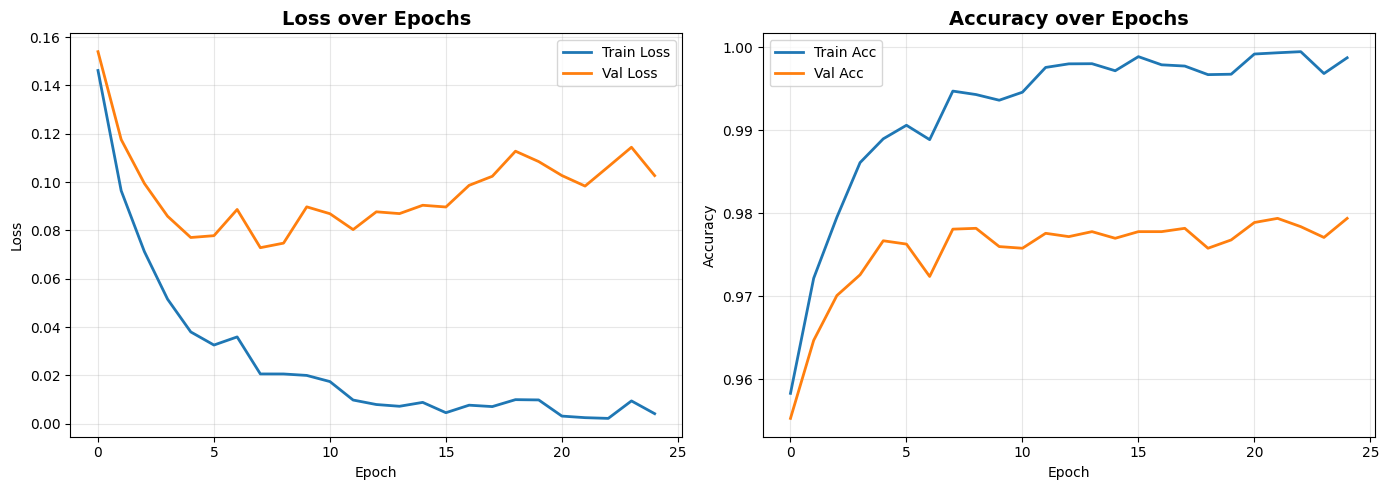

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nn.history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(nn.history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Loss over Epochs", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(nn.history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(nn.history["val_acc"], label="Val Acc", linewidth=2)
axes[1].set_title("Accuracy over Epochs", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **Confusion Matrix**

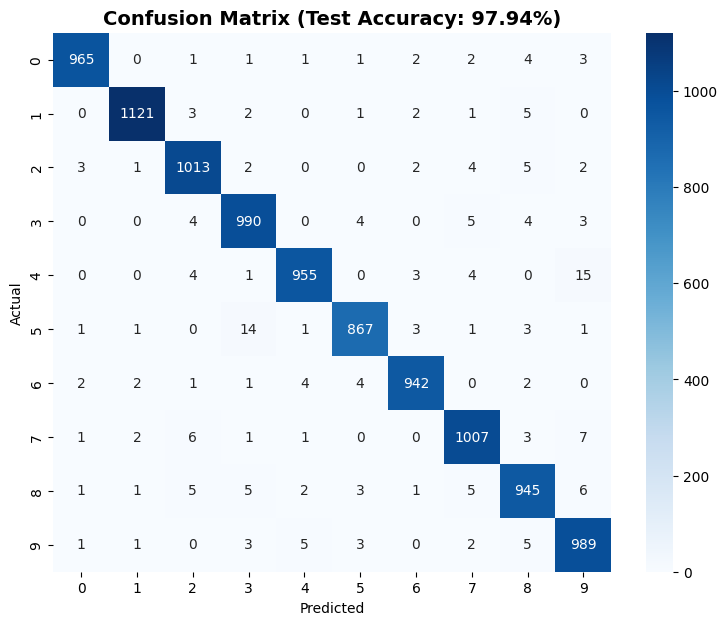

In [ ]:
preds = nn.predict(X_test)
true_labels = np.argmax(y_test, axis=0)
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Test Accuracy: {np.mean(preds==true_labels)*100:.2f}%)",
          fontsize=14, fontweight="bold")
plt.show()

## **Sample Predictions Grid**

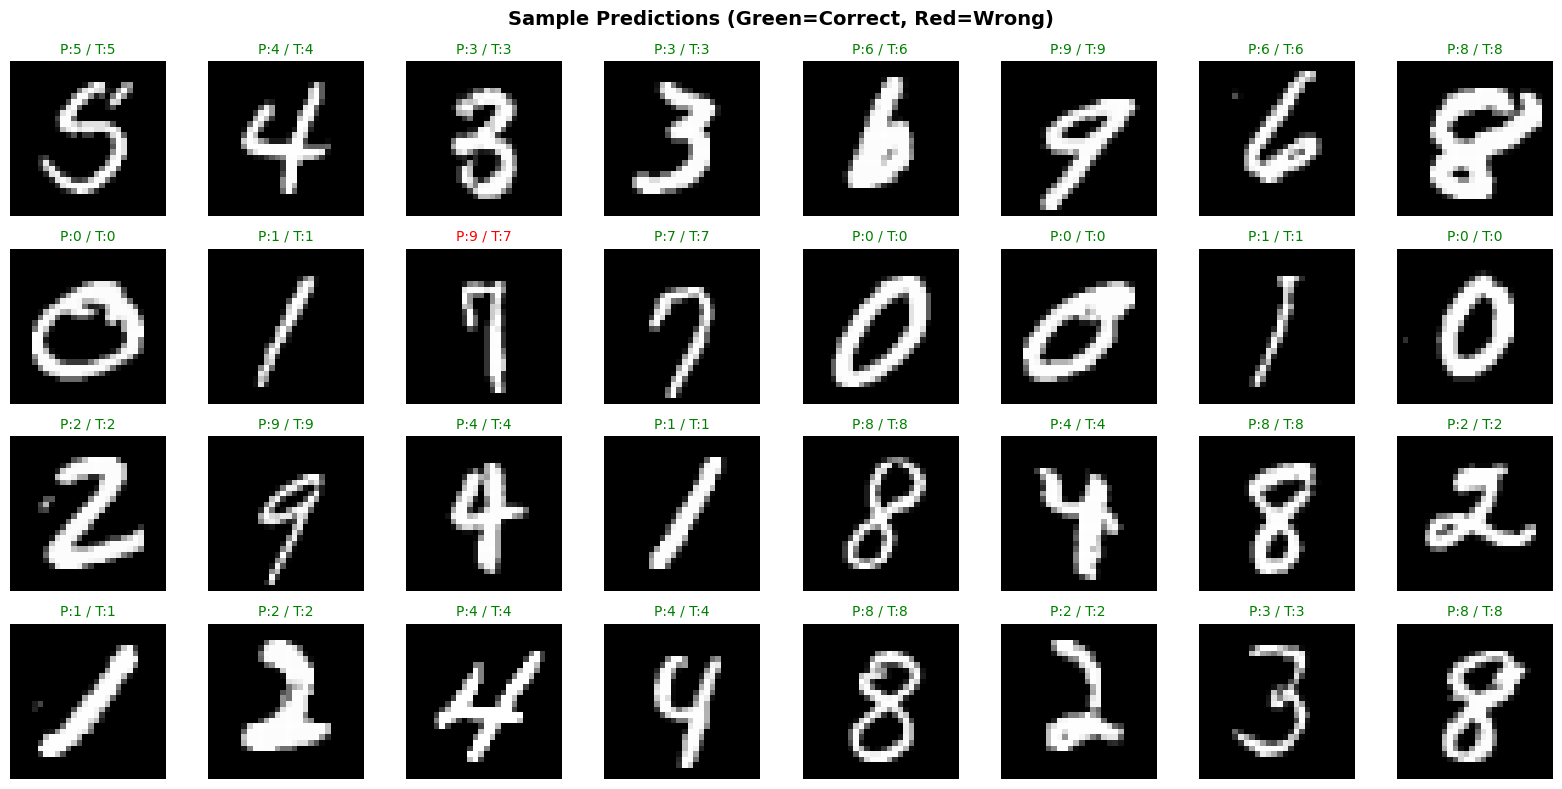

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
idxs = np.random.choice(X_test.shape[1], 32, replace=False)

for ax, idx in zip(axes.flat, idxs):
    img = X_test[:, idx].reshape(28, 28)
    pred, true = preds[idx], true_labels[idx]
    ax.imshow(img, cmap="gray")
    color = "green" if pred == true else "red"
    ax.set_title(f"P:{pred} / T:{true}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **What the First Layer "Sees" (Learned Weights)**

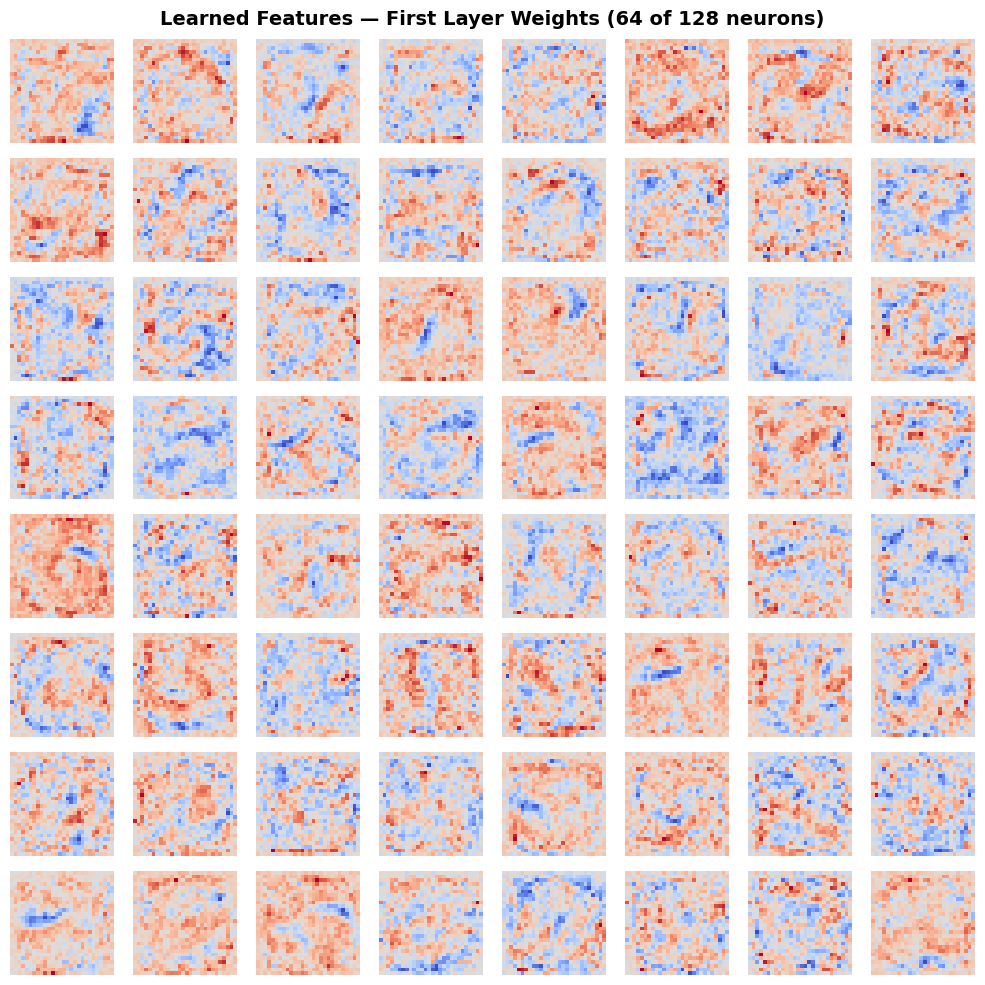

In [ ]:
W1 = nn.params["W1"]  # shape (128, 784)
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(W1[i].reshape(28, 28), cmap="coolwarm")
    ax.axis("off")

plt.suptitle("Learned Features — First Layer Weights (64 of 128 neurons)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Global Style (make everything look clean)**

In [ ]:
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
sns.set_palette("husl")

## **Per-Class Precision / Recall / F1 Bar Chart**

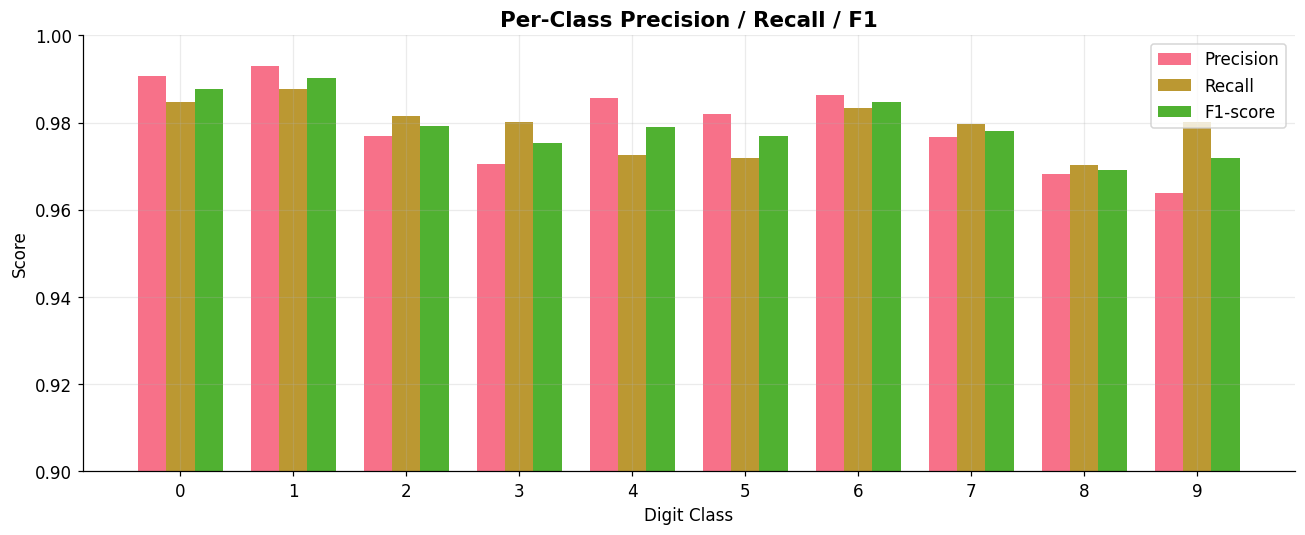

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(true_labels, preds)

x = np.arange(10)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1, width, label="F1-score")
ax.set_xticks(x); ax.set_xticklabels(x)
ax.set_xlabel("Digit Class"); ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.set_ylim(0.9, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## **Prediction Confidence Distribution**

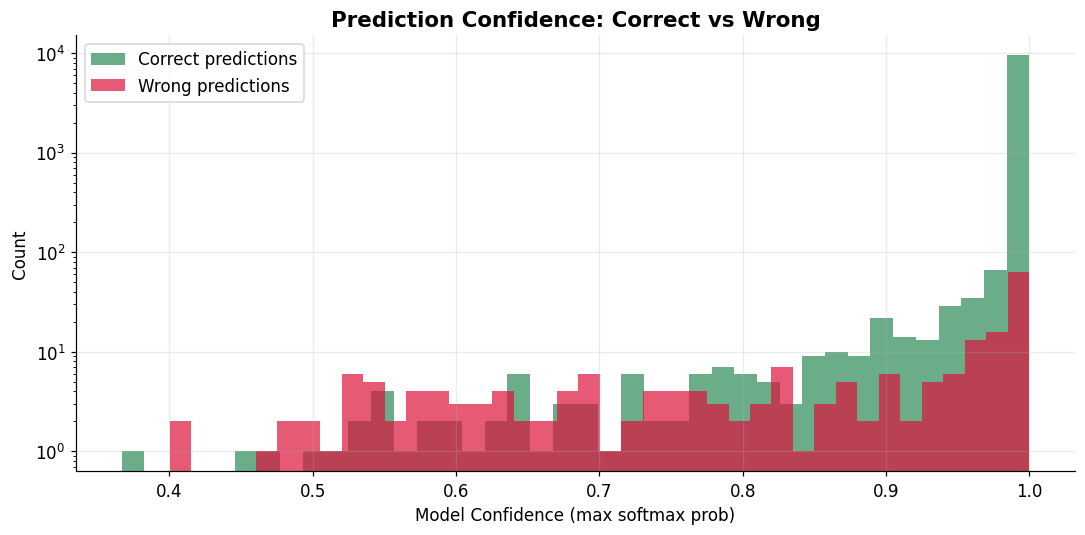

In [ ]:
Y_hat_test, _ = nn.forward(X_test)
confidences = np.max(Y_hat_test, axis=0)
correct_mask = preds == true_labels

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(confidences[correct_mask], bins=40, alpha=0.7, label="Correct predictions", color="seagreen")
ax.hist(confidences[~correct_mask], bins=40, alpha=0.7, label="Wrong predictions", color="crimson")
ax.set_xlabel("Model Confidence (max softmax prob)")
ax.set_ylabel("Count")
ax.set_title("Prediction Confidence: Correct vs Wrong", fontsize=14, fontweight="bold")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

## **Hardest Misclassified Examples (highest confidence wrong answers)**

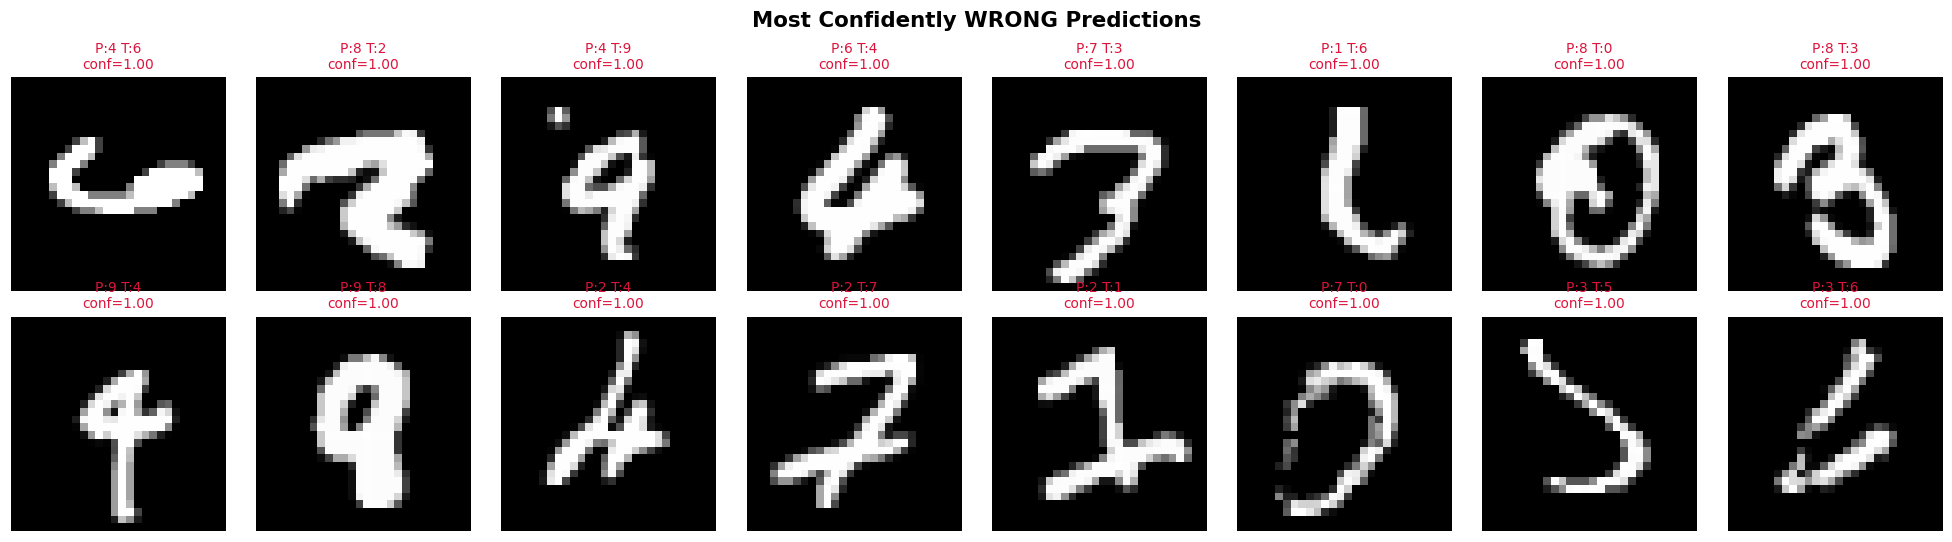

In [ ]:
wrong_idx = np.where(~correct_mask)[0]
wrong_conf = confidences[wrong_idx]
worst = wrong_idx[np.argsort(-wrong_conf)][:16]  # most confidently wrong

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for ax, idx in zip(axes.flat, worst):
    img = X_test[:, idx].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"P:{preds[idx]} T:{true_labels[idx]}\nconf={confidences[idx]:.2f}",
                 color="crimson", fontsize=9)
    ax.axis("off")

plt.suptitle("Most Confidently WRONG Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Weight Distribution Across Layers**

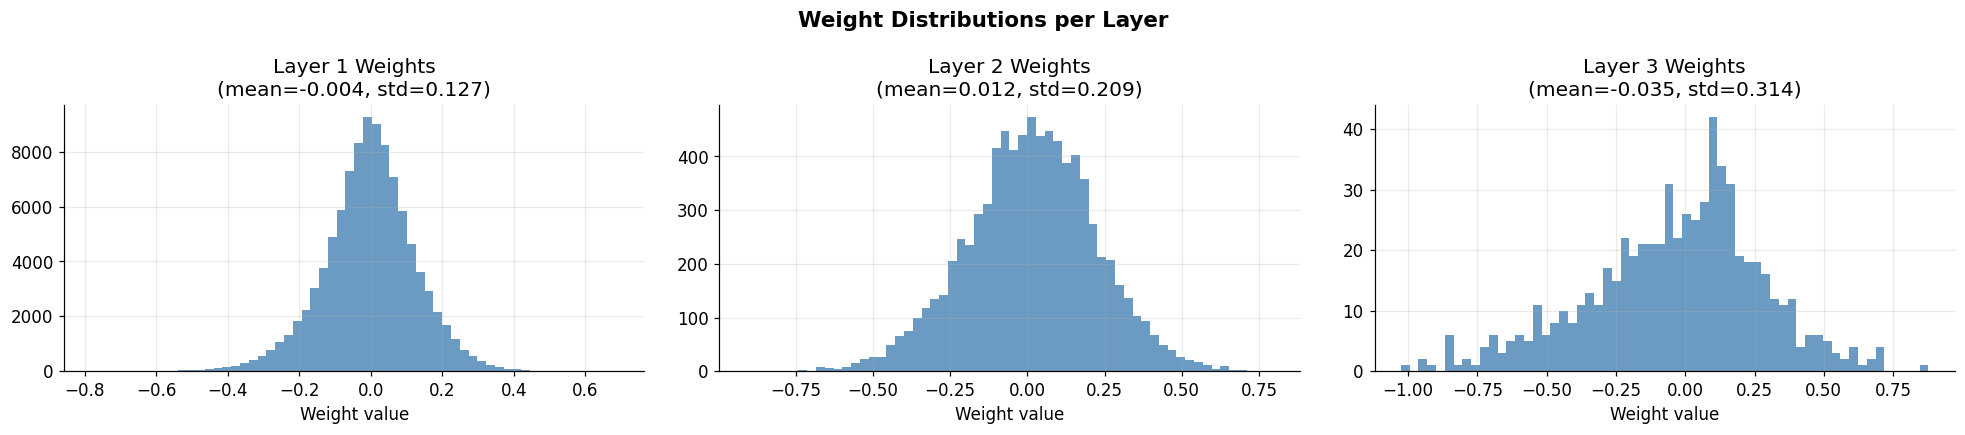

In [ ]:
fig, axes = plt.subplots(1, nn.L, figsize=(6*nn.L, 4))
if nn.L == 1: axes = [axes]

for l in range(1, nn.L + 1):
    W = nn.params[f"W{l}"].flatten()
    axes[l-1].hist(W, bins=60, color="steelblue", alpha=0.8)
    axes[l-1].set_title(f"Layer {l} Weights\n(mean={W.mean():.3f}, std={W.std():.3f})")
    axes[l-1].set_xlabel("Weight value")

plt.suptitle("Weight Distributions per Layer", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **Hidden Layer Activations for One Digit (Neuron Firing Pattern)**

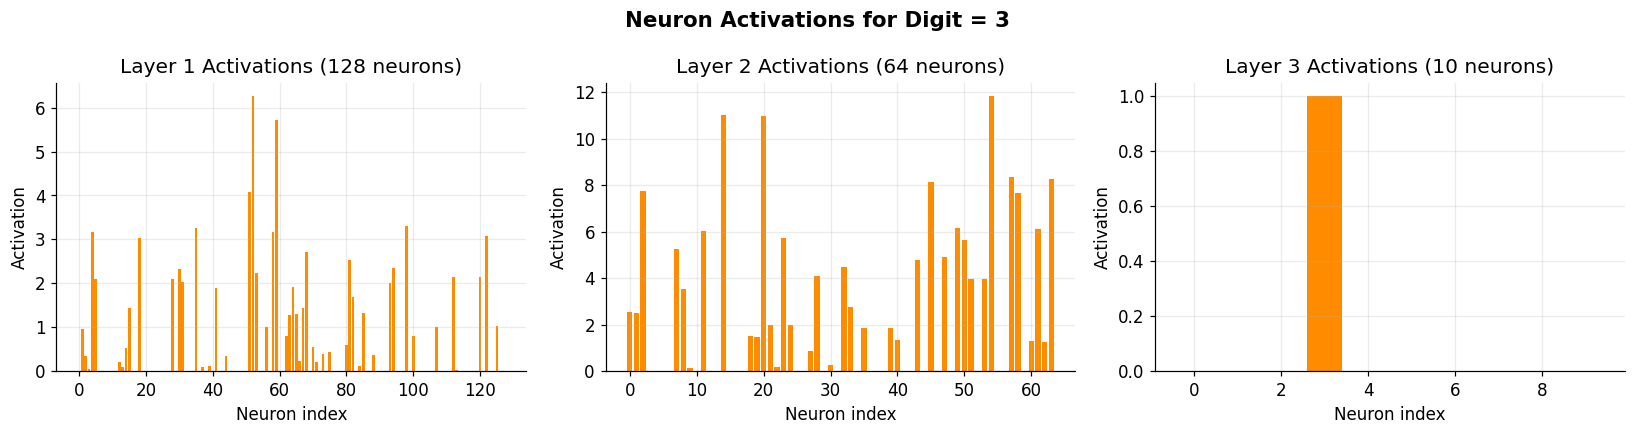

In [ ]:
sample_idx = np.random.randint(X_test.shape[1])
_, cache = nn.forward(X_test[:, sample_idx:sample_idx+1])

fig, axes = plt.subplots(1, nn.L, figsize=(5*nn.L, 4))
if nn.L == 1: axes = [axes]

for l in range(1, nn.L + 1):
    A = cache[f"A{l}"].flatten()
    axes[l-1].bar(range(len(A)), A, color="darkorange")
    axes[l-1].set_title(f"Layer {l} Activations ({len(A)} neurons)")
    axes[l-1].set_xlabel("Neuron index"); axes[l-1].set_ylabel("Activation")

plt.suptitle(f"Neuron Activations for Digit = {true_labels[sample_idx]}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## **2D Projection of Learned Representations (PCA)**

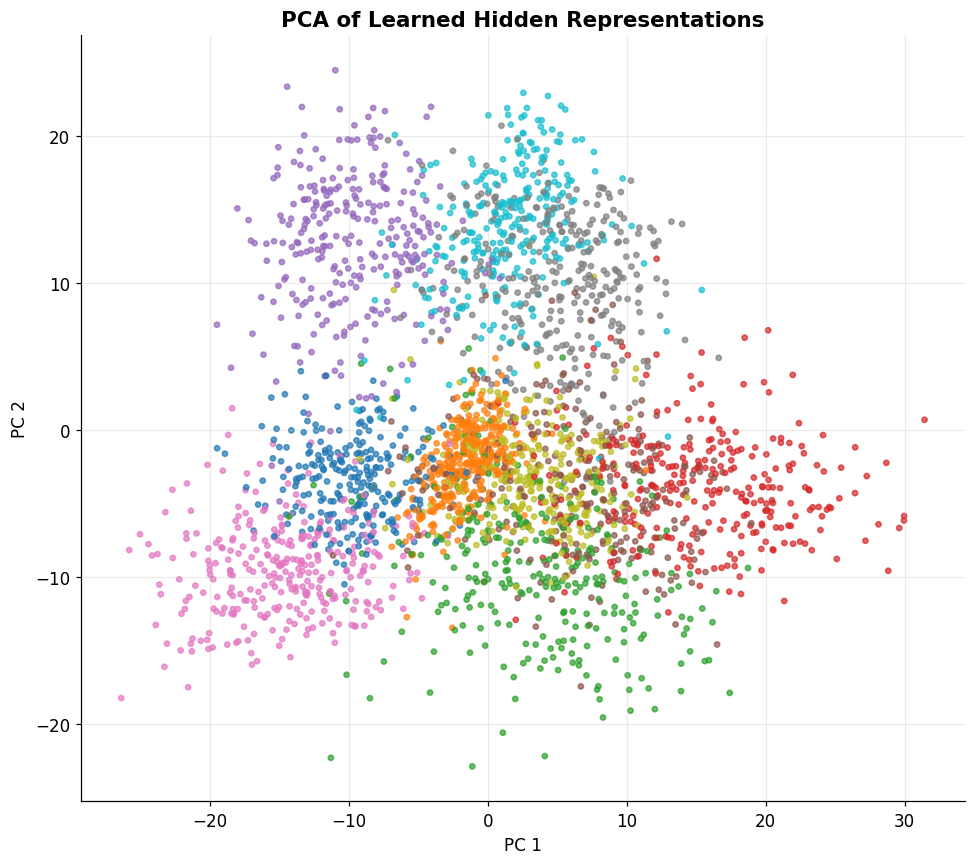

In [ ]:
from sklearn.decomposition import PCA

# Grab the last hidden layer's activations for a subset of test samples
subset = np.random.choice(X_test.shape[1], 3000, replace=False)
_, cache = nn.forward(X_test[:, subset])
last_hidden = cache[f"A{nn.L - 1}"].T  # (samples, features)

pca = PCA(n_components=2)
proj = pca.fit_transform(last_hidden)

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(proj[:, 0], proj[:, 1], c=true_labels[subset], cmap="tab10", s=12, alpha=0.7)
legend1 = ax.legend(*scatter.legend_elements(), title="Digit", loc="best", bbox_to_anchor=(1.15, 1))
ax.add_artist(legend1)
ax.set_title("PCA of Learned Hidden Representations", fontsize=14, fontweight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()

## **Summary Dashboard (all key metrics in one figure)**

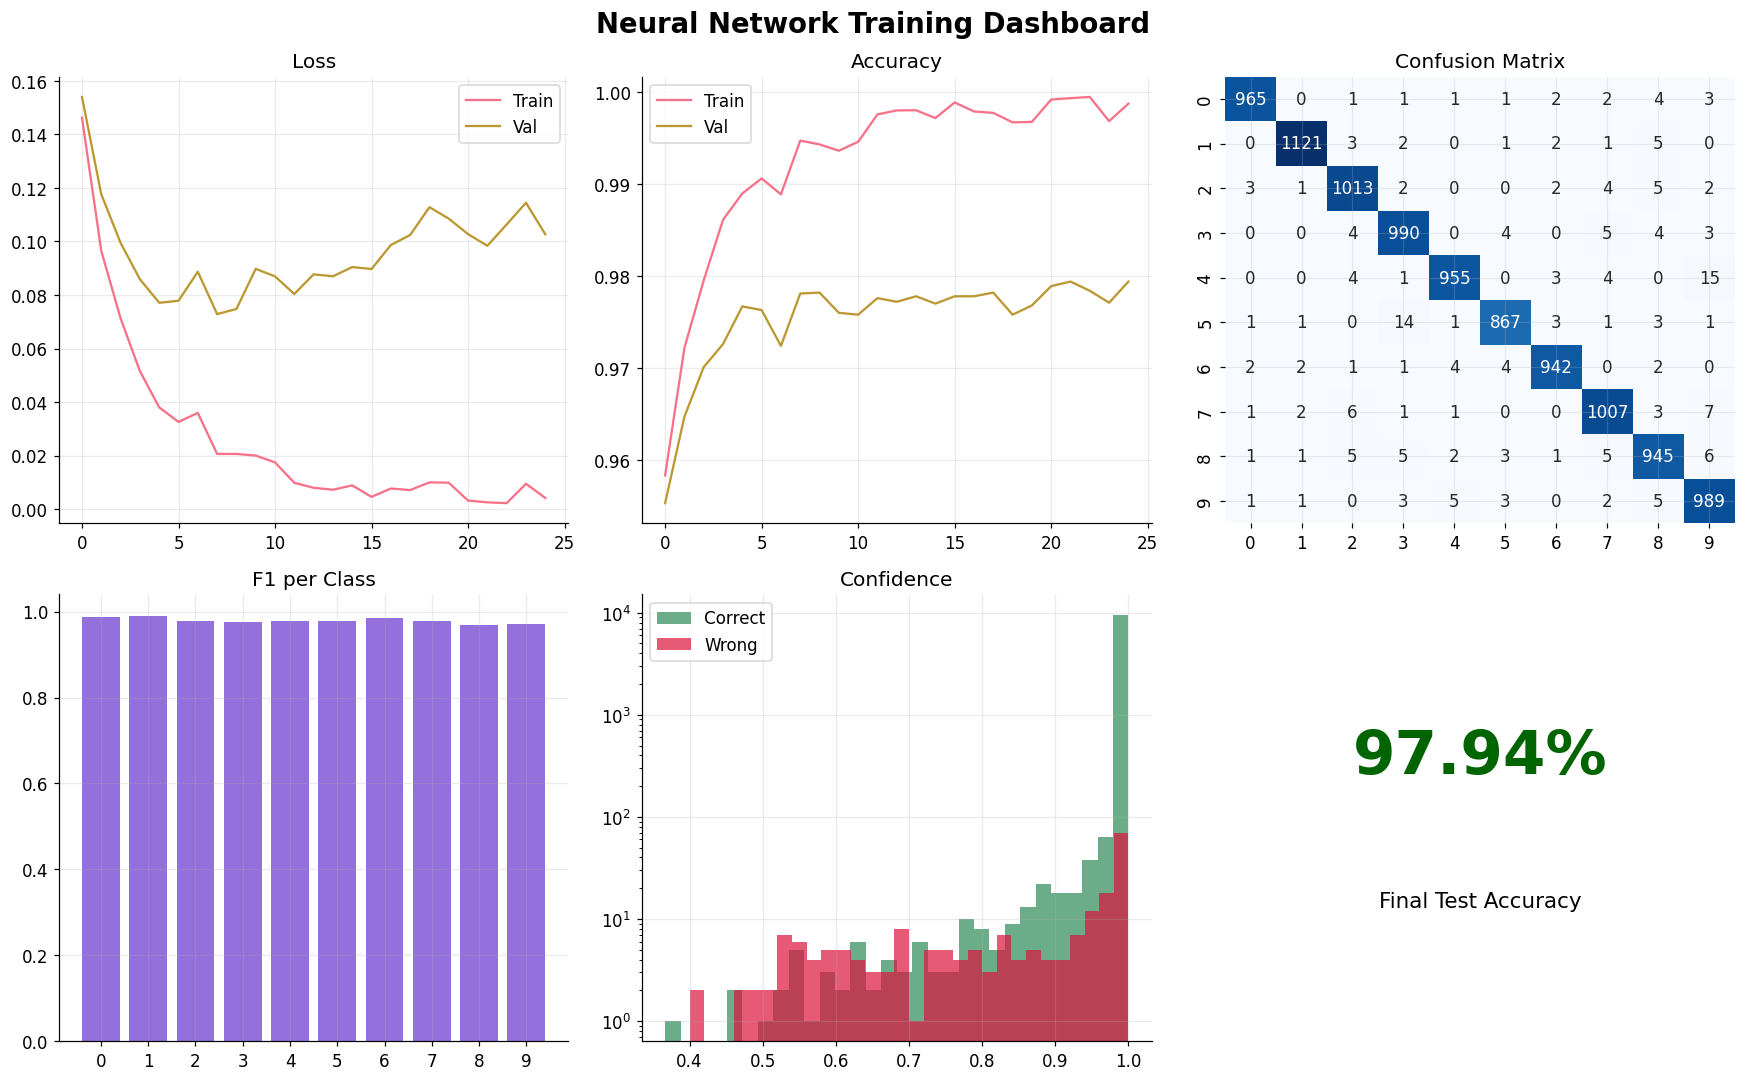

In [ ]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(nn.history["train_loss"], label="Train"); ax1.plot(nn.history["val_loss"], label="Val")
ax1.set_title("Loss"); ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(nn.history["train_acc"], label="Train"); ax2.plot(nn.history["val_acc"], label="Val")
ax2.set_title("Accuracy"); ax2.legend()

ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3, cbar=False)
ax3.set_title("Confusion Matrix")

ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(x, f1, color="mediumpurple")
ax4.set_title("F1 per Class"); ax4.set_xticks(x)

ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(confidences[correct_mask], bins=30, alpha=0.7, label="Correct", color="seagreen")
ax5.hist(confidences[~correct_mask], bins=30, alpha=0.7, label="Wrong", color="crimson")
ax5.set_yscale("log"); ax5.set_title("Confidence"); ax5.legend()

ax6 = fig.add_subplot(gs[1, 2])
final_acc = nn.history["val_acc"][-1] * 100
ax6.text(0.5, 0.6, f"{final_acc:.2f}%", fontsize=40, ha="center", fontweight="bold", color="darkgreen")
ax6.text(0.5, 0.3, "Final Test Accuracy", fontsize=14, ha="center")
ax6.axis("off")

plt.suptitle("Neural Network Training Dashboard", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()